===============================================
Notebook 10 — Search Dashboard (Notebook-native, ipywidgets)
Features:
- Search for Case / Resource / Event / Municipality by id
- Show profile pages, aggregated summaries, simple plots
- Export a PDF report for the current entity
- Uses only notebook UI (ipywidgets) and standard libs
===============================================

In [1]:
# ===============================================
# Code Block 1 — Imports, Paths, and Basic Checks
# ===============================================
import os
import math
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import ticker
from reportlab.lib.pagesizes import A4
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Image, Table, TableStyle
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.lib import colors

# Base directory
BASE = "../data"

# Output directory for PDF reports
OUTPUT_DIR = r"D:\WORK\PRJ-4\Project\outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Input files
FILES = {
    "cases_final" : os.path.join(BASE, "final", "cases_final.csv"),
    "resources_final": os.path.join(BASE, "final", "resources_final.csv"),
    "municipalities_final": os.path.join(BASE, "final", "municipalities_final.csv"),
    "full_report": os.path.join(BASE, "final", "full_performance_report.csv"),
    "case_hybrid": os.path.join(BASE, "processed", "case_hybrid_scores.csv"),
    "event_scores": os.path.join(BASE, "processed", "event_scores.csv"),
    "hybrid_model": os.path.join(BASE, "processed", "hybrid_performance_model.csv"),
    "resource_hybrid": os.path.join(BASE, "processed", "resource_hybrid_scores.csv"),
}

missing = [k for k,p in FILES.items() if not os.path.exists(p)]
if missing:
    print("Missing (ignored):", missing)

print("\nLoaded files:")
for k,p in FILES.items():
    if os.path.exists(p):
        print("  *", k, "->", p)



Loaded files:
  * cases_final -> ../data\final\cases_final.csv
  * resources_final -> ../data\final\resources_final.csv
  * municipalities_final -> ../data\final\municipalities_final.csv
  * full_report -> ../data\final\full_performance_report.csv
  * case_hybrid -> ../data\processed\case_hybrid_scores.csv
  * event_scores -> ../data\processed\event_scores.csv
  * hybrid_model -> ../data\processed\hybrid_performance_model.csv
  * resource_hybrid -> ../data\processed\resource_hybrid_scores.csv


In [2]:
# ===============================================
# Code Block 2 — Load datasets and initial validation
# ===============================================

def safe_read_csv(path, **kwargs):
    try:
        return pd.read_csv(path, **kwargs)
    except:
        return None

cases_final = safe_read_csv(FILES["cases_final"])
resources_final = safe_read_csv(FILES["resources_final"])
municipalities_final = safe_read_csv(FILES["municipalities_final"])
full_report = safe_read_csv(FILES["full_report"])
case_hybrid = safe_read_csv(FILES["case_hybrid"])
event_scores = safe_read_csv(FILES["event_scores"])
resource_hybrid = safe_read_csv(FILES["resource_hybrid"])
hybrid_model = safe_read_csv(FILES["hybrid_model"])

# Convert IDs to strings where relevant
def ensure_str(df, col):
    if df is not None and col in df.columns:
        df[col] = df[col].astype(str)
    return df

cases_final = ensure_str(cases_final, "case_id")
case_hybrid = ensure_str(case_hybrid, "case_id")
event_scores = ensure_str(event_scores, "case_id")
resources_final = ensure_str(resources_final, "resource")
resource_hybrid = ensure_str(resource_hybrid, "resource")
municipalities_final = ensure_str(municipalities_final, "municipality")
hybrid_model = ensure_str(hybrid_model, "municipality")

print("\nLoaded datasets:")
for name, df in [
    ("cases_final", cases_final),
    ("resources_final", resources_final),
    ("municipalities_final", municipalities_final),
    ("full_report", full_report),
    ("case_hybrid", case_hybrid),
    ("event_scores", event_scores),
    ("resource_hybrid", resource_hybrid),
    ("hybrid_model", hybrid_model),
]:
    if df is not None:
        print(name, df.shape)


C:\Users\likhi\AppData\Local\Temp\ipykernel_20524\4096670152.py:7: DtypeWarning: Columns (1,2) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(path, **kwargs)



Loaded datasets:
cases_final (3183, 8)
resources_final (64, 7)
municipalities_final (5, 39)
full_report (262628, 20)
case_hybrid (3183, 4)
event_scores (262628, 13)
resource_hybrid (64, 4)
hybrid_model (5, 34)


C:\Users\likhi\AppData\Local\Temp\ipykernel_20524\4096670152.py:7: DtypeWarning: Columns (1,2) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(path, **kwargs)


In [3]:
# ===============================================
# Code Block 3 — Utility search & aggregation functions
# ===============================================

def find_case(case_id):
    case_id = str(case_id)
    out = {"case_id": case_id}

    # Base case row
    if cases_final is not None:
        row = cases_final[cases_final.case_id == case_id]
        out["case_row"] = row.iloc[0].to_dict() if not row.empty else None

    # Events
    if event_scores is not None:
        ev = event_scores[event_scores.case_id == case_id]
        out["events"] = ev.sort_values("event_score", ascending=False)

    # Case hybrid
    if case_hybrid is not None:
        ch = case_hybrid[case_hybrid.case_id == case_id]
        out["case_hybrid"] = ch.iloc[0].to_dict() if not ch.empty else None

    # Resources in this case
    if resources_final is not None and "events" in out:
        res_list = out["events"]["resource"].dropna().unique().astype(str)
        res_rows = resources_final[resources_final.resource.isin(res_list)]
        if resource_hybrid is not None:
            res_rows = res_rows.merge(resource_hybrid, on="resource", how="left")
        out["resources"] = res_rows

    return out


def find_resource(resource):
    resource = str(resource)
    out = {}

    if resources_final is not None:
        row = resources_final[resources_final.resource == resource]
        out["resource_row"] = row.iloc[0].to_dict() if not row.empty else None

    if event_scores is not None:
        ev = event_scores[event_scores.resource == resource]
        out["events"] = ev.sort_values("event_score", ascending=False)

    # Average case hybrid score
    if case_hybrid is not None and not ev.empty:
        cids = ev["case_id"].unique()
        out["avg_case_hybrid"] = float(
            case_hybrid[case_hybrid.case_id.isin(cids)]["case_hybrid_score"].mean()
        )

    # Resource hybrid
    if resource_hybrid is not None:
        rh = resource_hybrid[resource_hybrid.resource == resource]
        out["resource_hybrid"] = rh.iloc[0].to_dict() if not rh.empty else None

    return out


def find_municipality(muni):
    muni = str(muni)
    out = {}

    if municipalities_final is not None:
        row = municipalities_final[municipalities_final.municipality == muni]
        out["muni_row"] = row.iloc[0].to_dict() if not row.empty else None

    # Case hybrid scores
    if case_hybrid is not None:
        ch = case_hybrid[case_hybrid.municipality == muni]
        out["case_count"] = len(ch)
        out["top_cases"] = ch.sort_values("case_hybrid_score", ascending=False).head(5)
        out["bottom_cases"] = ch.sort_values("case_hybrid_score").head(5)

    # Resources for muni
    if resource_hybrid is not None:
        rh = resource_hybrid[resource_hybrid.municipality == muni]
        out["resource_count"] = len(rh)
        out["top_resources"] = rh.sort_values("resource_hybrid_score", ascending=False).head(5)

    # Municipality hybrid
    if hybrid_model is not None:
        hm = hybrid_model[hybrid_model.municipality == muni]
        out["muni_hybrid"] = hm.iloc[0].to_dict() if not hm.empty else None

    return out


In [4]:
# ===============================================
# Code Block 4 — PDF report generator
# ===============================================

def _round_values(d):
    out = {}
    for k,v in d.items():
        if isinstance(v, float):
            out[k] = round(v, 3)
        else:
            out[k] = v
    return out

def create_pdf_search_report(out_path, title, profile_dict, extra_tables=None, fig=None):
    doc = SimpleDocTemplate(out_path, pagesize=A4)
    styles = getSampleStyleSheet()
    story = []

    # Title
    story.append(Paragraph(title, styles["Title"]))
    story.append(Spacer(1, 10))

    # Basic table
    if profile_dict:
        rows = [[k, str(v)] for k,v in _round_values(profile_dict).items()]
        tbl = Table(rows, colWidths=[150, 350])
        tbl.setStyle(TableStyle([("GRID", (0,0), (-1,-1), 0.25, colors.grey)]))
        story.append(tbl)
        story.append(Spacer(1, 12))

    # Additional tables
    if extra_tables:
        for ttitle, df in extra_tables:
            story.append(Paragraph(ttitle, styles["Heading3"]))
            story.append(Spacer(1, 6))

            df2 = df.head(12).fillna("").astype(str)
            data = [list(df2.columns)] + df2.values.tolist()
            t = Table(data, repeatRows=1)
            t.setStyle(TableStyle([
                ("BACKGROUND", (0,0), (-1,0), colors.lightgrey),
                ("GRID", (0,0), (-1,-1), 0.25, colors.grey),
            ]))
            story.append(t)
            story.append(Spacer(1, 12))

    # Optional figure
    if fig is not None:
        buf = io.BytesIO()
        fig.savefig(buf, format="png", dpi=120, bbox_inches="tight")
        buf.seek(0)
        story.append(Image(buf, width=400, height=250))
        story.append(Spacer(1, 12))

    doc.build(story)
    return out_path


In [5]:
# ===============================================
# Code Block 5 — Plot Helpers
# ===============================================

def plot_case_timeline(profile):
    ev = profile.get("events")
    if ev is None or ev.empty:
        fig = plt.figure(figsize=(6,2))
        plt.text(0.5,0.5,"No events", ha="center", va="center")
        plt.axis("off")
        return fig

    if "timestamp" in ev.columns:
        ev = ev.sort_values("timestamp")

    fig, ax = plt.subplots(figsize=(7,2.5))
    ax.plot(ev["event_score"].values, marker="o")
    ax.set_ylim(0,1)
    ax.set_title(f"Event Score Timeline (Case {profile['case_id']})")
    return fig


In [6]:
# ===============================================
# Code Block 6 — Search Function (Case / Resource / Municipality)
# ===============================================

def search_and_show(entity_type, entity_id, export_pdf=False, pdf_path=None):
    entity_type = entity_type.lower()

    if entity_type == "case":
        p = find_case(entity_id)
        print("\n=== CASE PROFILE ===")
        display(p.get("case_row"))
        display(p.get("case_hybrid"))
        display(p.get("events").head(10))
        display(p.get("resources").head(10))

        fig = plot_case_timeline(p)
        plt.show(fig)

        if export_pdf:
            pdf_path = pdf_path or os.path.join(OUTPUT_DIR, f"case_{entity_id}.pdf")
            create_pdf_search_report(pdf_path, f"Case {entity_id}", p.get("case_row") or {},
                                     extra_tables=[("Events", p.get("events"))],
                                     fig=fig)
            print("PDF saved to:", pdf_path)
        return p

    if entity_type == "resource":
        p = find_resource(entity_id)
        print("\n=== RESOURCE PROFILE ===")
        display(p.get("resource_row"))
        display(p.get("events").head(10))
        display(p.get("resource_hybrid"))

        if export_pdf:
            pdf_path = pdf_path or os.path.join(OUTPUT_DIR, f"resource_{entity_id}.pdf")
            create_pdf_search_report(pdf_path, f"Resource {entity_id}", p.get("resource_row") or {},
                                     extra_tables=[("Events", p.get("events"))])
            print("PDF saved to:", pdf_path)
        return p

    if entity_type == "municipality":
        p = find_municipality(entity_id)
        print("\n=== MUNICIPALITY PROFILE ===")
        display(p.get("muni_row"))
        display(p.get("muni_hybrid"))
        display(p.get("top_cases"))
        display(p.get("top_resources"))

        if export_pdf:
            pdf_path = pdf_path or os.path.join(OUTPUT_DIR, f"municipality_{entity_id}.pdf")
            create_pdf_search_report(pdf_path, f"Municipality {entity_id}", p.get("muni_row") or {},
                                     extra_tables=[
                                         ("Top Cases", p.get("top_cases")),
                                         ("Top Resources", p.get("top_resources")),
                                     ])
            print("PDF saved to:", pdf_path)
        return p



=== CASE PROFILE ===


{'case_id': '11330151',
 'municipality': 'BPIC15_4',
 'case_hybrid_score': 0.842,
 'case_hybrid_raw': 0.8355437075681589,
 'n_events_case': 32,
 'event_score_mean': 0.779,
 'event_score_median': 0.798,
 'avg_resource_score_in_case': 0.469}

{'case_id': '11330151',
 'municipality': 'BPIC15_4',
 'case_hybrid_score': 0.842,
 'case_hybrid_raw': 0.8355437075681589}

,event_id,case_id,resource,event_score,ev_prev_gap,ev_next_gap,ev_gap_ratio_prev,ev_rework_prior,ev_event_pos,ev_activity_freq,ev_resource_freq,ev_case_score,ev_resource_score
9644,NaN,11330151,1550894,0.882,0.722,0.722,0.722,0.738,0.970,0.983,0.369,0.762,0.469
9645,NaN,11330151,1550894,0.867,0.722,0.722,0.722,0.738,0.958,0.829,0.369,0.762,0.469
9646,NaN,11330151,1550894,0.863,0.722,0.722,0.722,0.738,0.946,0.808,0.369,0.762,0.469
9649,NaN,11330151,1550894,0.859,0.722,0.722,0.722,0.738,0.910,0.861,0.369,0.762,0.469
9653,NaN,11330151,1550894,0.855,0.722,0.722,0.722,0.738,0.863,0.949,0.369,0.762,0.469
9658,NaN,11330151,1550894,0.828,0.722,0.722,0.722,0.738,0.806,0.780,0.369,0.762,0.469
9648,NaN,11330151,1550894,0.826,0.722,0.722,0.722,0.738,0.922,0.437,0.369,0.762,0.469
9647,NaN,11330151,1550894,0.825,0.722,0.722,0.722,0.738,0.934,0.384,0.369,0.762,0.469
9660,NaN,11330151,1550894,0.821,0.722,0.722,0.722,0.738,0.784,0.753,0.369,0.762,0.469
9659,NaN,11330151,1550894,0.810,0.722,0.722,0.722,0.738,0.795,0.599,0.369,0.762,0.469


,resource,municipality_x,resource_hybrid_score_x,resource_hybrid_raw_x,n_events_handled,event_score_mean_resource,avg_case_hybrid_score,municipality_y,resource_hybrid_score_y,resource_hybrid_raw_y
0,1550894,BPIC15_4,0.582,0.458375,12875,0.513,0.642,BPIC15_4,0.582,0.458375


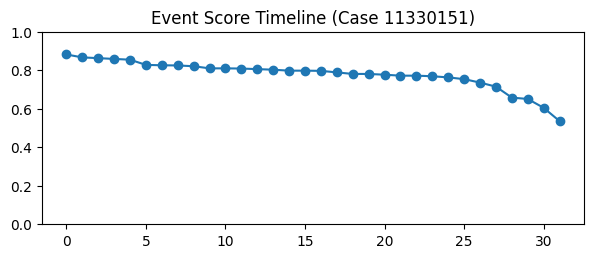

PDF saved to: D:\WORK\PRJ-4\Project\outputs\case_11330151.pdf


{'case_id': '11330151',
 'case_row': {'case_id': '11330151',
  'municipality': 'BPIC15_4',
  'case_hybrid_score': 0.842,
  'case_hybrid_raw': 0.8355437075681589,
  'n_events_case': 32,
  'event_score_mean': 0.779,
  'event_score_median': 0.798,
  'avg_resource_score_in_case': 0.469},
 'events':       event_id   case_id resource  event_score  ev_prev_gap  ev_next_gap  \
 9644       NaN  11330151  1550894        0.882        0.722        0.722   
 9645       NaN  11330151  1550894        0.867        0.722        0.722   
 9646       NaN  11330151  1550894        0.863        0.722        0.722   
 9649       NaN  11330151  1550894        0.859        0.722        0.722   
 9653       NaN  11330151  1550894        0.855        0.722        0.722   
 9658       NaN  11330151  1550894        0.828        0.722        0.722   
 9648       NaN  11330151  1550894        0.826        0.722        0.722   
 9647       NaN  11330151  1550894        0.825        0.722        0.722   
 9660       

In [8]:
search_and_show("case", "11330151", export_pdf=True)
